##Premier League Machine Learning Model
### Danial N., Adam S., Alexa W.

###Connect Colab to your Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


###Each user must specify their personal file path:

In [ ]:
import os

# TODO: Fill in the Google Drive path where you uploaded the assignment, it should be under CS3540/CS3540-Assignments/yournetid-A4
ALEXA = '---'
ADAM = '---' # change this directory to yours
DAN = '---' # change this directory to yours
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = ADAM # Change to your name before running
GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

['CS3540-Assignments', 'Premier_League_ML.ipynb', 'CSML Project Proposal Report Format.gdoc']


###Import/load all necessary modules and utilities:

In [ ]:
# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn utilities
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler

# sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler

# Varying types of visualizations from decision_tree.ipynb
from sklearn.tree import export_graphviz # may need to pip install graphviz
from graphviz import Source # may need to pip install graphviz
from matplotlib.colors import ListedColormap

# used in assignment 3 with logistic regression / non-linear logistic regression
from past.builtins import xrange
from scipy.special import expit

%matplotlib inline

# import API requests and JSON handling
import requests, json
from pprint import pprint


In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

###Helpful Source for Loading in JSON File:
https://medium.com/analytics-vidhya/getting-started-with-fantasy-premier-league-data-56d3b9be8c32

##Import FPL API Bootstrap Data
### Main URL for all premier league players, teams, global gameweek summaries
#### Current Season: 2025/26


In [ ]:
# define base url for FPL API endpoints
#https://fantasy.premierleague.com/api/bootstrap-static/
base_url = 'https://fantasy.premierleague.com/api/'

# retireve JSON data from bootstrap-static endpoint for previous and current season
bootstrap_2223 = requests.get('https://web.archive.org/web/20230530110013/https://fantasy.premierleague.com/api/bootstrap-static/').json() # May 30 using Wayback Machine
bootstrap_2324 = requests.get('https://web.archive.org/web/20240522000017/https://fantasy.premierleague.com/api/bootstrap-static/').json() # May 22 using Wayback Machine
bootstrap_2425 = requests.get('https://web.archive.org/web/20250526110039/https://fantasy.premierleague.com/api/bootstrap-static/').json() # May 26 using Wayback Machine
bootstrap_2526 = requests.get(base_url+'bootstrap-static/').json()

# display headings for data
print(list(bootstrap_2526))

['chips', 'events', 'game_settings', 'game_config', 'phases', 'teams', 'total_players', 'element_stats', 'element_types', 'elements']


## Retrieve Player Data from Bootstrap API


In [ ]:
# elements contains data for each player
elements_2223 = bootstrap_2223['elements']
elements_2324 = bootstrap_2324['elements']
elements_2425 = bootstrap_2425['elements']
elements_2526 = bootstrap_2526['elements']

# load into DataFrame
players_2223 = pd.json_normalize(elements_2223)
players_2324 = pd.json_normalize(elements_2324)
players_2425 = pd.json_normalize(elements_2425)
players_2526 = pd.json_normalize(elements_2526)

# display headers of player data
print(list(players_2526.columns))

# display some data of players
display(players_2425[['id', 'web_name', 'team', 'total_points', 'team', 'element_type']].head())
print('-------------------------------------------------------------')
display(players_2526[['id', 'web_name', 'team', 'total_points', 'team', 'element_type']].head())
#As seen here the infromation about each player can be dificult to read as the team and position information is stored as ids

['can_transact', 'can_select', 'chance_of_playing_next_round', 'chance_of_playing_this_round', 'code', 'cost_change_event', 'cost_change_event_fall', 'cost_change_start', 'cost_change_start_fall', 'price_change_percent', 'dreamteam_count', 'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name', 'form', 'id', 'in_dreamteam', 'news', 'news_added', 'now_cost', 'photo', 'points_per_game', 'removed', 'second_name', 'selected_by_percent', 'special', 'squad_number', 'status', 'team', 'team_code', 'total_points', 'transfers_in', 'transfers_in_event', 'transfers_out', 'transfers_out_event', 'value_form', 'value_season', 'web_name', 'known_name', 'region', 'team_join_date', 'birth_date', 'has_temporary_code', 'opta_code', 'minutes', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded', 'own_goals', 'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards', 'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat', 'ict_index', 'clearances_blocks_interceptions', 're

,id,web_name,team,total_points,team,element_type
0,1,Fábio Vieira,1,0,1,3
1,2,G.Jesus,1,42,1,4
2,3,Gabriel,1,117,1,2
3,4,Havertz,1,97,1,4
4,5,Hein,1,0,1,1


-------------------------------------------------------------


,id,web_name,team,total_points,team,element_type
0,1,Raya,1,122,1,1
1,2,Arrizabalaga,1,0,1,1
2,3,Hein,1,0,1,1
3,4,Setford,1,0,1,1
4,5,Gabriel,1,164,1,2


## Retrieve Team Data from Bootstrap API

In [ ]:
# teams contains data on each team
teams_2223 = bootstrap_2223['teams']
teams_2324 = bootstrap_2324['teams']
teams_2425 = bootstrap_2425['teams']
teams_2526 = bootstrap_2425['teams']

# load into DataFrame
clubs_2223 = pd.json_normalize(teams_2223)
clubs_2324 = pd.json_normalize(teams_2324)
clubs_2425 = pd.json_normalize(teams_2425)
clubs_2526 = pd.json_normalize(teams_2526)

# display headers of team data
print(list(clubs_2526.columns))

# display some data of teams
pd.set_option('display.max_columns', None)
display(clubs_2425.head())
print('-------------------------------------------------------------')
display(clubs_2526.head())

['code', 'draw', 'form', 'id', 'loss', 'name', 'played', 'points', 'position', 'short_name', 'strength', 'team_division', 'unavailable', 'win', 'strength_overall_home', 'strength_overall_away', 'strength_attack_home', 'strength_attack_away', 'strength_defence_home', 'strength_defence_away', 'pulse_id']


,code,draw,form,id,loss,name,played,points,position,short_name,strength,team_division,unavailable,win,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,3,0,None,1,0,Arsenal,0,0,2,ARS,5,None,False,0,1350,1350,1390,1400,1310,1300,1
1,7,0,None,2,0,Aston Villa,0,0,6,AVL,3,None,False,0,1145,1240,1130,1180,1160,1300,2
2,91,0,None,3,0,Bournemouth,0,0,9,BOU,3,None,False,0,1170,1200,1120,1180,1220,1220,127
3,94,0,None,4,0,Brentford,0,0,10,BRE,3,None,False,0,1130,1180,1100,1100,1160,1260,130
4,36,0,None,5,0,Brighton,0,0,8,BHA,3,None,False,0,1140,1165,1090,1140,1190,1190,131


-------------------------------------------------------------


,code,draw,form,id,loss,name,played,points,position,short_name,strength,team_division,unavailable,win,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,pulse_id
0,3,0,None,1,0,Arsenal,0,0,2,ARS,5,None,False,0,1350,1350,1390,1400,1310,1300,1
1,7,0,None,2,0,Aston Villa,0,0,6,AVL,3,None,False,0,1145,1240,1130,1180,1160,1300,2
2,91,0,None,3,0,Bournemouth,0,0,9,BOU,3,None,False,0,1170,1200,1120,1180,1220,1220,127
3,94,0,None,4,0,Brentford,0,0,10,BRE,3,None,False,0,1130,1180,1100,1100,1160,1260,130
4,36,0,None,5,0,Brighton,0,0,8,BHA,3,None,False,0,1140,1165,1090,1140,1190,1190,131


## Retrieve Postion Data from Bootstrap API

In [ ]:
# element_types contains data on each position
element_types_2223 = bootstrap_2223['element_types']
element_types_2324 = bootstrap_2324['element_types']
element_types_2425 = bootstrap_2425['element_types']
element_types_2526 = bootstrap_2526['element_types']

# load into DataFrame
positions_2223 = pd.json_normalize(element_types_2223)
positions_2324 = pd.json_normalize(element_types_2324)
positions_2425 = pd.json_normalize(element_types_2425)
positions_2526 = pd.json_normalize(element_types_2526)

# display headers of position data
print(list(positions_2526.columns))

# display some data of positions
display(positions_2425.head())
print('-------------------------------------------------------------')
display(positions_2526.head())

['id', 'plural_name', 'plural_name_short', 'singular_name', 'singular_name_short', 'squad_select', 'squad_min_select', 'squad_max_select', 'squad_min_play', 'squad_max_play', 'ui_shirt_specific', 'sub_positions_locked', 'element_count']


,id,plural_name,plural_name_short,singular_name,singular_name_short,squad_select,squad_min_select,squad_max_select,squad_min_play,squad_max_play,ui_shirt_specific,sub_positions_locked,element_count
0,1,Goalkeepers,GKP,Goalkeeper,GKP,2,None,None,1,1,True,[12],82
1,2,Defenders,DEF,Defender,DEF,5,None,None,3,5,False,[],268
2,3,Midfielders,MID,Midfielder,MID,5,None,None,2,5,False,[],347
3,4,Forwards,FWD,Forward,FWD,3,None,None,1,3,False,[],87
4,5,Managers,MNG,Manager,MNG,0,None,None,0,0,True,[],20


-------------------------------------------------------------


,id,plural_name,plural_name_short,singular_name,singular_name_short,squad_select,squad_min_select,squad_max_select,squad_min_play,squad_max_play,ui_shirt_specific,sub_positions_locked,element_count
0,1,Goalkeepers,GKP,Goalkeeper,GKP,2,None,None,1,1,True,[12],94
1,2,Defenders,DEF,Defender,DEF,5,None,None,3,5,False,[],266
2,3,Midfielders,MID,Midfielder,MID,5,None,None,2,5,False,[],368
3,4,Forwards,FWD,Forward,FWD,3,None,None,1,3,False,[],92


## Merge Player DataFrame with Team and Position DataFrame to display id's Interms of Actual Team and Position Names

In [ ]:
# rename headers in player, team and position tabels prior to merging
players_data_2223 = players_2223.rename(columns={'id':'player_id'})
players_data_2324 = players_2324.rename(columns={'id':'player_id'})
players_data_2425 = players_2425.rename(columns={'id':'player_id'})
players_data_2526 = players_2526.rename(columns={'id':'player_id'})

clubs_data_2223= clubs_2223.rename(columns={'id':'team_id', 'name':'team_name'})
clubs_data_2324 = clubs_2324.rename(columns={'id':'team_id', 'name':'team_name'})
clubs_data_2425 = clubs_2425.rename(columns={'id':'team_id', 'name':'team_name'})
clubs_data_2526 = clubs_2526.rename(columns={'id':'team_id', 'name':'team_name'})

positions_data_2223 = positions_2223.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})
positions_data_2324 = positions_2324.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})
positions_data_2425 = positions_2425.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})
positions_data_2526 = positions_2526.rename(columns={'id':'position_id', 'singular_name_short':'position_name'})

# build previous season DataFrames
# map team data
playerInfo_2223 = pd.merge(
    left = players_data_2223,
    right = clubs_data_2223,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2223 = playerInfo_2223.merge(
    positions_data_2223,
    left_on='element_type',
    right_on='position_id')

# map team data
playerInfo_2324 = pd.merge(
    left = players_data_2324,
    right = clubs_data_2324,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2324 = playerInfo_2324.merge(
    positions_data_2324,
    left_on='element_type',
    right_on='position_id')

# map team data
playerInfo_2425 = pd.merge(
    left = players_data_2425,
    right = clubs_data_2425,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2425 = playerInfo_2425.merge(
    positions_data_2425,
    left_on='element_type',
    right_on='position_id')

# build current season DataFrames
# map team data
playerInfo_2526 = pd.merge(
    left = players_data_2526,
    right = clubs_data_2526,
    left_on = 'team',
    right_on = 'team_id')

# map position data
playerInfo_2526 = playerInfo_2526.merge(
    positions_data_2526,
    left_on='element_type',
    right_on='position_id')


# display new DataFrames
display(playerInfo_2425[['player_id', 'web_name', 'team_id', 'team_name', 'position_id', 'position_name']].head())
print('-------------------------------------------------------------')
display(playerInfo_2526[['player_id','web_name', 'team_id', 'team_name', 'position_id', 'position_name']].head())

,player_id,web_name,team_id,team_name,position_id,position_name
0,1,Fábio Vieira,1,Arsenal,3,MID
1,2,G.Jesus,1,Arsenal,4,FWD
2,3,Gabriel,1,Arsenal,2,DEF
3,4,Havertz,1,Arsenal,4,FWD
4,5,Hein,1,Arsenal,1,GKP


-------------------------------------------------------------


,player_id,web_name,team_id,team_name,position_id,position_name
0,1,Raya,1,Arsenal,1,GKP
1,2,Arrizabalaga,1,Arsenal,1,GKP
2,3,Hein,1,Arsenal,1,GKP
3,4,Setford,1,Arsenal,1,GKP
4,5,Gabriel,1,Arsenal,2,DEF


##Import FPL API Gameweek History Data for Current Season

In [ ]:
def gameweek_history(player_id):
    '''get all gameweek info for a given player_id
    source: https://medium.com/analytics-vidhya/getting-started-with-fantasy-premier-league-data-56d3b9be8c32'''

    # send GET request to
    # https://fantasy.premierleague.com/api/element-summary/{PID}/
    gameweek_2526 = requests.get( base_url + 'element-summary/' + str(player_id) + '/').json()


    # history contains data for each gameweek
    history_2526 = gameweek_2526['history']

    # load into DataFrame
    gw_history_2526 = pd.json_normalize(history_2526)

    return gw_history_2526

# create empty list to store gameweek history for all players
all_gw_2526 = []

# loop through all player ids to get gameweek history data
for player_id in list(playerInfo_2526['player_id']):
  # get current player gameweek history DataFrame
  df = gameweek_history(player_id)

  # get player web name and id for current player id
  player_info = playerInfo_2526[playerInfo_2526['player_id'] == player_id].iloc[0]
  df['player_id'] = player_info['player_id']
  df['web_name'] = player_info['web_name']

  # append DataFrame to list
  all_gw_2526.append(df)


# combine all players data into one DataFrame
points_history_2526 = pd.concat(all_gw_2526, ignore_index=True) # reset indicies

# display headers of data
print(list(points_history_2526))

# display part of data
points_history_2526[['round', 'player_id', 'web_name', 'total_points']].head()

['element', 'fixture', 'opponent_team', 'total_points', 'was_home', 'kickoff_time', 'team_h_score', 'team_a_score', 'round', 'modified', 'minutes', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded', 'own_goals', 'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards', 'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat', 'ict_index', 'clearances_blocks_interceptions', 'recoveries', 'tackles', 'defensive_contribution', 'starts', 'expected_goals', 'expected_assists', 'expected_goal_involvements', 'expected_goals_conceded', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'player_id', 'web_name']


,round,player_id,web_name,total_points
0,1,1,Raya,10
1,2,1,Raya,6
2,3,1,Raya,2
3,4,1,Raya,6
4,5,1,Raya,2


## Create Local Clone of Git Repository Containing Previous Seasons Data

In [ ]:
# this is one of the most popular githubs for FPL data collection
!git clone https://github.com/vaastav/Fantasy-Premier-League.git

Cloning into 'Fantasy-Premier-League'...
remote: Enumerating objects: 413787, done.
remote: Counting objects: 100% (2991/2991), done.
remote: Compressing objects: 100% (2366/2366), done.
remote: Total 413787 (delta 2327), reused 632 (delta 625), pack-reused 410796 (from 3)
Receiving objects: 100% (413787/413787), 175.79 MiB | 18.72 MiB/s, done.
Resolving deltas: 100% (214282/214282), done.
Updating files: 100% (17481/17481), done.


## Store FPL Previous Season Gameweek History Data for Each Player

In [ ]:
# define base url for acessing players data from previous season (20/21 and 21/22 season do not have XG and XA stats)
#base_path_2021 = './Fantasy-Premier-League/data/2020-21/players/'
#base_path_2122 = './Fantasy-Premier-League/data/2021-22/players/'
base_path_2223 = './Fantasy-Premier-League/data/2022-23/players/'
base_path_2324 = './Fantasy-Premier-League/data/2023-24/players/'
base_path_2425 = './Fantasy-Premier-League/data/2024-25/players/'

# create empty list to store gameweek history for all players
#all_gw_2021= []
#all_gw_2122= []
all_gw_2223= []
all_gw_2324 = []
all_gw_2425 = []

def prev_gameweek_history(base_path, list):
  # loop through each players folder
  for folder in os.listdir(base_path):
      folder_path = os.path.join(base_path, folder) # define path to folder ex folder name.) Aaron_Anselmino_774
      gw_file = os.path.join(folder_path, 'gw.csv') # acsess gw.csv that stores data from each gameweek
      #final output ex.) https://github.com/vaastav/Fantasy-Premier-League/blob/master/data/2024-25/players/Aaron_Anselmino_774/gw.csv

      # check path is valid
      if os.path.exists(gw_file):
          df = pd.read_csv(gw_file) # read csv and store as DataFrame

          # add player name and id from folder name
          first_name, last_name, player_id = folder.rsplit('_', 2) # ex.) Aaron_Anselmino_774 --> firstname_lastname_playerid
          df['player_id'] = int(player_id)
          df['first_name'] = first_name
          df['last_name'] = last_name
          df['web_name'] = first_name + " " + last_name

          # append DataFrame to list
          list.append(df)

  # combine all players data into one DataFrame
  points_history = pd.concat(list, ignore_index=True) # reset indicies
  return points_history

# get gameweek history of previous seasons
#points_history_2021 = prev_gameweek_history(base_path_2021, all_gw_2021)
#points_history_2122 = prev_gameweek_history(base_path_2122, all_gw_2122)
points_history_2223 = prev_gameweek_history(base_path_2223, all_gw_2223)
points_history_2324 = prev_gameweek_history(base_path_2324, all_gw_2324)
points_history_2425 = prev_gameweek_history(base_path_2425, all_gw_2425)

# display headers of data
#print(list(points_history_2021))
#print(list(points_history_2122))
print(list(points_history_2223))
print(list(points_history_2324))
print(list(points_history_2425))

# display part of data
display(points_history_2223[['round', 'player_id', 'web_name', 'total_points']].head())
display(points_history_2324[['round', 'player_id', 'web_name', 'total_points']].head())
display(points_history_2425[['round', 'player_id', 'web_name', 'total_points']].head())

['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'player_id', 'first_name', 'last_name', 'web_name']
['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score',

,round,player_id,web_name,total_points
0,1,132,Mateo Kovacic,0
1,2,132,Mateo Kovacic,0
2,3,132,Mateo Kovacic,0
3,4,132,Mateo Kovacic,1
4,5,132,Mateo Kovacic,1


,round,player_id,web_name,total_points
0,1,233,Remi Matthews,0
1,2,233,Remi Matthews,0
2,3,233,Remi Matthews,0
3,4,233,Remi Matthews,0
4,5,233,Remi Matthews,0


,round,player_id,web_name,total_points
0,1,197,Malcolm Ebiowei,0
1,2,197,Malcolm Ebiowei,0
2,3,197,Malcolm Ebiowei,0
3,4,197,Malcolm Ebiowei,0
4,5,197,Malcolm Ebiowei,0


## Merge Team Info and Position Info with Player Gameweek History

In [ ]:
df_2223 = pd.merge(
    left = points_history_2223,
    right = playerInfo_2223[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)
df_2324 = pd.merge(
    left = points_history_2324,
    right = playerInfo_2324[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)

df_2425 = pd.merge(
    left = points_history_2425,
    right = playerInfo_2425[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)

df_2526 = pd.merge(
    left = points_history_2526,
    right = playerInfo_2526[['player_id','team_id','team_name','position_id','position_name']],
    on='player_id', # match rows when player id is the same in both df
    how='left' # keeps rows from left table while adding matching rows from right table
)


# display headers of data
print(list(df_2223))
print(list(df_2324))
print(list(df_2425))
print(list(df_2526))

# display part of data
display(df_2425[['round', 'player_id', 'web_name', 'total_points', 'team_name', 'position_name', 'position_id']].head())
display(df_2526[['round', 'player_id', 'web_name', 'total_points', 'team_name', 'position_name', 'position_id']].head())

['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts', 'team_a_score', 'team_h_score', 'threat', 'total_points', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards', 'player_id', 'first_name', 'last_name', 'web_name', 'team_id', 'team_name', 'position_id', 'position_name']
['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves

,round,player_id,web_name,total_points,team_name,position_name,position_id
0,1,197,Malcolm Ebiowei,0,Crystal Palace,MID,3
1,2,197,Malcolm Ebiowei,0,Crystal Palace,MID,3
2,3,197,Malcolm Ebiowei,0,Crystal Palace,MID,3
3,4,197,Malcolm Ebiowei,0,Crystal Palace,MID,3
4,5,197,Malcolm Ebiowei,0,Crystal Palace,MID,3


,round,player_id,web_name,total_points,team_name,position_name,position_id
0,1,1,Raya,10,Arsenal,GKP,1
1,2,1,Raya,6,Arsenal,GKP,1
2,3,1,Raya,2,Arsenal,GKP,1
3,4,1,Raya,6,Arsenal,GKP,1
4,5,1,Raya,2,Arsenal,GKP,1


## Split DataFrame Based on Position and Key Feateures

In [ ]:
# split data based on position
gk_2223 = df_2223[df_2223['position_id'] == 1].copy()
def_2223 = df_2223[df_2223['position_id'] == 2].copy()
mid_2223 = df_2223[df_2223['position_id'] == 3].copy()
fwd_2223 = df_2223[df_2223['position_id'] == 4].copy()

gk_2324 = df_2324[df_2324['position_id'] == 1].copy()
def_2324 = df_2324[df_2324['position_id'] == 2].copy()
mid_2324 = df_2324[df_2324['position_id'] == 3].copy()
fwd_2324 = df_2324[df_2324['position_id'] == 4].copy()

gk_2425 = df_2425[df_2425['position_id'] == 1].copy()
def_2425 = df_2425[df_2425['position_id'] == 2].copy()
mid_2425 = df_2425[df_2425['position_id'] == 3].copy()
fwd_2425 = df_2425[df_2425['position_id'] == 4].copy()

gk_2526 = df_2526[df_2526['position_id'] == 1].copy()
def_2526 = df_2526[df_2526['position_id'] == 2].copy()
mid_2526 = df_2526[df_2526['position_id'] == 3].copy()
fwd_2526 = df_2526[df_2526['position_id'] == 4].copy()

# select relevant features for each position
id_features= ['player_id', 'web_name', 'team_id', 'team_name', 'position_id',
              'position_name', 'round']


gk_features = [
    'bonus', 'bps', 'clean_sheets',
    'expected_goals_conceded', 'goals_conceded',
    'ict_index', 'influence', 'minutes',
    'own_goals', 'penalties_saved',
    'red_cards', 'saves', 'selected', 'starts', 'team_a_score',
    'team_h_score', 'threat', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]

def_features = [
    'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'expected_goals_conceded', 'goals_conceded', 'goals_scored',
    'ict_index', 'influence',  'minutes',
     'own_goals', 'penalties_missed',
    'red_cards',   'selected', 'starts', 'team_a_score',
    'team_h_score', 'threat', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]

mid_features = [
    'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'expected_goals_conceded',  'goals_conceded', 'goals_scored',
    'ict_index', 'influence',  'minutes',
     'own_goals', 'penalties_missed',
    'red_cards', 'selected', 'starts', 'team_a_score',
    'team_h_score', 'threat', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]

fwd_features = [
    'assists', 'bonus', 'bps',  'creativity',
    'expected_assists', 'expected_goal_involvements', 'expected_goals',
    'goals_scored', 'ict_index', 'influence',  'minutes',
    'own_goals', 'penalties_missed',
    'red_cards',  'selected', 'starts', 'team_a_score',
    'team_h_score', 'total_points', 'transfers_balance',
    'transfers_in', 'transfers_out', 'value', 'was_home', 'yellow_cards',
]

# keep only desired columns (also reset indices for split data)
gk_2223 = gk_2223[id_features + gk_features].reset_index(drop=True)
def_2223 = def_2223[id_features + def_features].reset_index(drop=True)
mid_2223 = mid_2223[id_features + mid_features].reset_index(drop=True)
fwd_2223 = fwd_2223[id_features + fwd_features].reset_index(drop=True)

gk_2324 = gk_2324[id_features + gk_features].reset_index(drop=True)
def_2324 = def_2324[id_features + def_features].reset_index(drop=True)
mid_2324 = mid_2324[id_features + mid_features].reset_index(drop=True)
fwd_2324 = fwd_2324[id_features + fwd_features].reset_index(drop=True)

gk_2425 = gk_2425[id_features + gk_features].reset_index(drop=True)
def_2425 = def_2425[id_features + def_features].reset_index(drop=True)
mid_2425 = mid_2425[id_features + mid_features].reset_index(drop=True)
fwd_2425 = fwd_2425[id_features + fwd_features].reset_index(drop=True)

gk_2526 = gk_2526[id_features + gk_features].reset_index(drop=True)
def_2526 = def_2526[id_features + def_features].reset_index(drop=True)
mid_2526= mid_2526[id_features + mid_features].reset_index(drop=True)
fwd_2526 = fwd_2526[id_features + fwd_features].reset_index(drop=True)

# display split data
#display(gk_2425.head())
#display(def_2425.head())
#display(mid_2425.head())
#display(fwd_2425.head())
display(gk_2526.head())
display(def_2526.head())
display(mid_2526.head())
display(fwd_2526.head())


,player_id,web_name,team_id,team_name,position_id,position_name,round,bonus,bps,clean_sheets,expected_goals_conceded,goals_conceded,ict_index,influence,minutes,own_goals,penalties_saved,red_cards,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,1,Raya,1,Arsenal,1,GKP,1,3,38,1,1.52,0,4.9,49.2,90,0,0,0,7,1531911,1,1,0,0.0,10,0,0,0,55,False,1
1,1,Raya,1,Arsenal,1,GKP,2,0,28,1,0.17,0,1.3,13.4,90,0,0,0,1,2284634,1,0,5,0.0,6,218659,277339,58680,55,True,0
2,1,Raya,1,Arsenal,1,GKP,3,0,12,0,0.52,1,3.0,20.0,90,0,0,0,2,2406964,1,0,1,0.0,2,-12311,146739,159050,55,False,0
3,1,Raya,1,Arsenal,1,GKP,4,0,24,1,0.20,0,1.3,12.8,90,0,0,0,1,2765759,1,0,3,0.0,6,171289,289041,117752,55,True,0
4,1,Raya,1,Arsenal,1,GKP,5,0,13,0,0.89,1,2.1,21.4,90,0,0,0,2,2762632,1,1,1,0.0,2,-9786,98100,107886,55,True,0


,player_id,web_name,team_id,team_name,position_id,position_name,round,assists,bonus,bps,clean_sheets,creativity,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,5,Gabriel,1,Arsenal,2,DEF,1,0,0,23,1,0.3,0.00,0.00,0.00,1.52,0,0,2.7,22.8,90,0,0,0,1696374,1,1,0,4.0,6,0,0,0,60,False,0
1,5,Gabriel,1,Arsenal,2,DEF,2,0,0,26,1,3.3,0.01,0.05,0.04,0.17,0,0,2.3,13.4,90,0,0,0,2292996,1,0,5,6.0,6,254939,335537,80598,60,True,0
2,5,Gabriel,1,Arsenal,2,DEF,3,0,0,8,0,1.4,0.01,0.03,0.02,0.52,1,0,1.9,15.4,90,0,0,0,2291736,1,0,1,2.0,2,-28048,137723,165771,61,False,0
3,5,Gabriel,1,Arsenal,2,DEF,4,0,1,32,1,1.3,0.01,0.21,0.20,0.20,0,0,3.8,28.0,90,0,0,0,2531223,1,0,3,9.0,9,89836,230780,140944,61,True,0
4,5,Gabriel,1,Arsenal,2,DEF,5,0,0,13,0,2.3,0.01,0.01,0.00,0.89,1,0,2.2,19.6,90,0,0,0,2599245,1,1,1,0.0,2,45804,134864,89060,61,True,0


,player_id,web_name,team_id,team_name,position_id,position_name,round,assists,bonus,bps,clean_sheets,creativity,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,16,Saka,1,Arsenal,3,MID,1,0,0,7,1,16.4,0.09,0.24,0.15,1.52,0,0,3.5,12.0,90,0,0,0,1602493,1,1,0,7.0,3,0,0,0,100,False,0
1,16,Saka,1,Arsenal,3,MID,2,0,0,27,0,30.4,0.03,0.14,0.11,0.17,0,1,9.2,40.4,52,0,0,0,1870918,1,0,5,21.0,6,43708,152171,108463,100,True,0
2,16,Saka,1,Arsenal,3,MID,3,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,783017,0,0,1,0.0,0,-986673,55049,1041722,99,False,0
3,16,Saka,1,Arsenal,3,MID,4,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,500371,0,0,3,0.0,0,-368029,5237,373266,98,True,0
4,16,Saka,1,Arsenal,3,MID,5,0,0,7,0,32.3,0.21,0.25,0.04,0.34,0,0,4.5,5.6,45,0,0,0,415767,0,1,1,7.0,1,-95794,1687,97481,98,True,0


,player_id,web_name,team_id,team_name,position_id,position_name,round,assists,bonus,bps,creativity,expected_assists,expected_goal_involvements,expected_goals,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,selected,starts,team_a_score,team_h_score,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards
0,30,Havertz,1,Arsenal,4,FWD,1,0,0,4,0.8,0.01,0.01,0.00,0,0.6,2.8,30,0,0,0,117967,0,1,0,1,0,0,0,75,False,0
1,30,Havertz,1,Arsenal,4,FWD,2,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,102996,0,0,5,0,-34363,7926,42289,75,True,0
2,30,Havertz,1,Arsenal,4,FWD,3,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,61485,0,0,1,0,-42500,185,42685,74,False,0
3,30,Havertz,1,Arsenal,4,FWD,4,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,51020,0,0,3,0,-12322,138,12460,74,True,0
4,30,Havertz,1,Arsenal,4,FWD,5,0,0,0,0.0,0.00,0.00,0.00,0,0.0,0.0,0,0,0,0,47388,0,1,1,0,-4105,111,4216,73,True,0


## Add a 5 Gameweek Rolling Average to Features and Create Target Value as Next Weeks Points Earned


In [ ]:
# define features not to average
current_features = ['selected', 'team_a_score', 'team_h_score',
                      'transfers_balance', 'transfers_in', 'transfers_out',
                      'value', 'was_home']

def data_prep(df, features):
  '''Function will take said DataFrame and correspoindg features and filter data
prior to applying ML model. Sort df by player_id and round. Next a target
variable (Y, next gws points) will be created for each row. Finally average features
over past 5-gameweeks to try and settle outliers'''

  # sort data by player_id first then round
  df = df.sort_values(by=['player_id', 'round'])

  # group together gw data for said player and add a feature 'target_points'
  # that is simply the total_points from the following gw (row), shifting back one row
  df['target_points'] = df.groupby('player_id')['total_points'].shift(-1)

  # also create new variable to let model know if a player played the next gameweek
  df['target_minutes'] = df.groupby('player_id')['minutes'].shift(-1)

  # create rolling avg for each position specific feature list based on previous 5 gws
  for feature in features:
    if feature not in current_features:
      # intitally group data by player_id and the feature being looked at
      grouped_player_feature = df.groupby('player_id')[feature]

      # define a rolling avergae of 5 gameweeks with the minimum being 1 gameweek (this is so it still calculates and avgerage at start of season)
      # .reset_index(0, drop=True) allows removes and resets index when using groupby and rolling
      df[f'avg_{feature}_5gws'] = grouped_player_feature.rolling(window = 5, min_periods=1).mean().reset_index(0, drop=True)

  # return formated DataFrame
  return df

# format data
gk_data_2223 = data_prep(gk_2223, gk_features)
def_data_2223 = data_prep(def_2223, def_features)
mid_data_2223 = data_prep(mid_2223, mid_features)
fwd_data_2223 = data_prep(fwd_2223, fwd_features)

gk_data_2324 = data_prep(gk_2324, gk_features)
def_data_2324 = data_prep(def_2324, def_features)
mid_data_2324 = data_prep(mid_2324, mid_features)
fwd_data_2324 = data_prep(fwd_2324, fwd_features)

gk_data_2425 = data_prep(gk_2425, gk_features)
def_data_2425  = data_prep(def_2425 , def_features)
mid_data_2425  = data_prep(mid_2425, mid_features)
fwd_data_2425  = data_prep(fwd_2425 , fwd_features)

gk_data_2526 = data_prep(gk_2526, gk_features)
def_data_2526 = data_prep(def_2526, def_features)
mid_data_2526 = data_prep(mid_2526, mid_features)
fwd_data_2526 = data_prep(fwd_2526, fwd_features)

# display data
#display(gk_data_2425)
display(def_data_2425)
#display(mid_data_2425)
#display(fwd_data_2425)



,player_id,web_name,team_id,team_name,position_id,position_name,round,assists,bonus,bps,clean_sheets,creativity,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,red_cards,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,target_points,target_minutes,avg_assists_5gws,avg_bonus_5gws,avg_bps_5gws,avg_clean_sheets_5gws,avg_creativity_5gws,avg_expected_assists_5gws,avg_expected_goal_involvements_5gws,avg_expected_goals_5gws,avg_expected_goals_conceded_5gws,avg_goals_conceded_5gws,avg_goals_scored_5gws,avg_ict_index_5gws,avg_influence_5gws,avg_minutes_5gws,avg_own_goals_5gws,avg_penalties_missed_5gws,avg_red_cards_5gws,avg_starts_5gws,avg_threat_5gws,avg_total_points_5gws,avg_yellow_cards_5gws
2753,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,1,0,0,22,1,1.4,0.02,0.14,0.12,0.47,0,0,2.3,13.8,90,0,0,0,1167503,1,0,2,8.0,6,0,0,0,60,True,0,6.0,90.0,0.0,0.000000,22.000000,1.000000,1.400000,0.020000,0.140000,0.1200,0.470000,0.000000,0.00,2.300000,13.800000,90.0,0.0,0.0,0.0,1.0,8.000000,6.000000,0.000000
2754,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,2,0,1,25,1,1.9,0.02,0.02,0.00,1.28,0,0,2.3,21.4,90,0,0,0,1248259,1,2,0,0.0,6,-25184,36723,61907,60,False,1,2.0,90.0,0.0,0.500000,23.500000,1.000000,1.650000,0.020000,0.080000,0.0600,0.875000,0.000000,0.00,2.300000,17.600000,90.0,0.0,0.0,0.0,1.0,4.000000,6.000000,0.500000
2755,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,3,0,0,17,0,20.8,0.01,0.13,0.12,1.83,1,0,5.1,20.8,90,0,0,0,1296327,1,1,1,9.0,2,853,86679,85826,60,True,0,15.0,90.0,0.0,0.333333,21.333333,0.666667,8.033333,0.016667,0.096667,0.0800,1.193333,0.333333,0.00,3.233333,18.666667,90.0,0.0,0.0,0.0,1.0,5.666667,4.666667,0.333333
2756,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,4,0,3,40,1,0.7,0.00,0.27,0.27,0.74,0,1,9.4,58.0,90,0,0,0,1208425,1,1,0,35.0,15,-115425,61041,176466,60,False,0,7.0,90.0,0.0,1.000000,26.000000,0.750000,6.200000,0.012500,0.140000,0.1275,1.080000,0.250000,0.25,4.775000,28.500000,90.0,0.0,0.0,0.0,1.0,13.000000,7.250000,0.250000
2757,3,Gabriel dos Santos Magalhães,1,Arsenal,2,DEF,5,0,0,15,0,0.8,0.01,0.50,0.49,2.16,2,1,9.7,56.6,90,0,0,0,1375740,1,2,2,40.0,7,131837,171534,39697,60,False,0,1.0,90.0,0.0,0.800000,23.800000,0.600000,5.120000,0.012000,0.212000,0.2000,1.296000,0.600000,0.40,5.760000,34.120000,90.0,0.0,0.0,0.0,1.0,18.400000,7.200000,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6001,801,Brayden Clarke,1,Arsenal,2,DEF,36,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,94,0,2,2,0.0,0,59,62,3,40,False,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
6002,801,Brayden Clarke,1,Arsenal,2,DEF,37,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,149,0,0,1,0.0,0,28,42,14,40,True,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
6003,801,Brayden Clarke,1,Arsenal,2,DEF,38,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,247,0,2,1,0.0,0,74,95,21,40,False,0,NaN,NaN,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3782,803,Reece Welch,8,Everton,2,DEF,38,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0,0,0.0,0.0,0,0,0,0,0,0,1,0,0.0,0,0,0,0,40,False,0,NaN,NaN,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


## Prepare Train and Test Set

In [ ]:
def data_cleaning(df, pos_features):
  '''Remove any rounds when a player did not play (no minutes = no points ), as total_points is taken
  from the following gameweek on the last round total_points equals NaN so need to remove those rows.
  Lastly the inputs of the data will be devined as the rolling averages while the target is total_points'''
  # remove data when no minutes are played
  df_played = df[df['minutes'] > 0].copy() # makes sure they played in this gw
  df_played2 = df_played[df_played['target_minutes'] > 0].copy() # makes sure they played next gw so target points is not 0

  # drop any rows with NaN
  df_cleaned = df_played2.dropna(subset=['target_points'])

  # create list for desired features to keep as inputs
  desired_features = []
  for feature in pos_features:
    if feature not in current_features:
      input_features = f'avg_{feature}_5gws'
      desired_features.append(input_features)

  for i in current_features:
    desired_features.append(i)

  # seperate X (inputs) and Y (target variable), also recent indices
  X = df_cleaned[desired_features].reset_index(drop=True)
  Y = df_cleaned['target_points'].reset_index(drop=True)

  return X, Y

# aquire training data (previous season)
X_gk_2223, Y_gk_2223 = data_cleaning(gk_data_2223, gk_features)
X_def_2223, Y_def_2223 = data_cleaning(def_data_2223, def_features)
X_mid_2223, Y_mid_2223 = data_cleaning(mid_data_2223, mid_features)
X_fwd_2223, Y_fwd_2223 = data_cleaning(fwd_data_2223, fwd_features)

X_gk_2324, Y_gk_2324 = data_cleaning(gk_data_2324, gk_features)
X_def_2324, Y_def_2324 = data_cleaning(def_data_2324, def_features)
X_mid_2324, Y_mid_2324 = data_cleaning(mid_data_2324, mid_features)
X_fwd_2324, Y_fwd_2324 = data_cleaning(fwd_data_2324, fwd_features)

X_gk_2425, Y_gk_2425 = data_cleaning(gk_data_2425, gk_features)
X_def_2425, Y_def_2425 = data_cleaning(def_data_2425, def_features)
X_mid_2425, Y_mid_2425 = data_cleaning(mid_data_2425, mid_features)
X_fwd_2425, Y_fwd_2425 = data_cleaning(fwd_data_2425, fwd_features)

X_train_gk = np.concatenate([X_gk_2223, X_gk_2324, X_gk_2425])
Y_train_gk = np.concatenate([Y_gk_2223, Y_gk_2324, Y_gk_2425])

X_train_def = np.concatenate([X_def_2223, X_def_2324, X_def_2425])
Y_train_def = np.concatenate([Y_def_2223, Y_def_2324, Y_def_2425])

X_train_mid = np.concatenate([X_mid_2223, X_mid_2324, X_mid_2425])
Y_train_mid = np.concatenate([Y_mid_2223, Y_mid_2324, Y_mid_2425])

X_train_fwd = np.concatenate([X_fwd_2223, X_fwd_2324, X_fwd_2425])
Y_train_fwd = np.concatenate([Y_fwd_2223, Y_fwd_2324, Y_fwd_2425])

# aquire test data (current season)
X_test_gk, Y_test_gk = data_cleaning(gk_data_2526, gk_features)
X_test_def, Y_test_def = data_cleaning(def_data_2526, def_features)
X_test_mid, Y_test_mid = data_cleaning(mid_data_2526, mid_features)
X_test_fwd, Y_test_fwd = data_cleaning(fwd_data_2526, fwd_features)

#display(X_gk_2223.head())
display(Y_test_fwd)
display(X_test_fwd)


,target_points
0,5.0
1,1.0
2,1.0
3,1.0
4,4.0
...,...
892,2.0
893,2.0
894,2.0
895,4.0


,avg_assists_5gws,avg_bonus_5gws,avg_bps_5gws,avg_creativity_5gws,avg_expected_assists_5gws,avg_expected_goal_involvements_5gws,avg_expected_goals_5gws,avg_goals_scored_5gws,avg_ict_index_5gws,avg_influence_5gws,avg_minutes_5gws,avg_own_goals_5gws,avg_penalties_missed_5gws,avg_red_cards_5gws,avg_starts_5gws,avg_total_points_5gws,avg_yellow_cards_5gws,selected,team_a_score,team_h_score,transfers_balance,transfers_in,transfers_out,value,was_home
0,0.000000,0.0,2.200000,2.140000,0.002000,0.002000,0.000,0.0,0.420000,1.560000,12.0,0.0,0.0,0.0,0.2,0.400000,0.000000,55362,4,0,10238,11934,1696,73,False
1,0.200000,0.0,5.800000,4.220000,0.008000,0.050000,0.042,0.0,1.220000,4.320000,16.0,0.0,0.0,0.0,0.2,1.200000,0.000000,66912,1,2,-15020,234,15254,73,True
2,0.000000,0.0,1.000000,0.120000,0.000000,0.024000,0.024,0.0,0.440000,0.840000,1.8,0.0,0.0,0.0,0.0,0.200000,0.000000,16239,1,2,7437,8455,1018,64,True
3,0.000000,0.0,1.000000,0.980000,0.004000,0.032000,0.028,0.0,0.680000,0.840000,6.8,0.0,0.0,0.0,0.0,0.400000,0.000000,24944,1,0,7452,10467,3015,64,False
4,0.000000,0.0,1.200000,1.240000,0.006000,0.052000,0.046,0.0,1.160000,1.400000,10.6,0.0,0.0,0.0,0.0,0.600000,0.000000,23738,1,2,-1320,3974,5294,64,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,1.000000,0.0,14.000000,11.300000,0.350000,0.350000,0.000,0.0,3.200000,16.600000,90.0,0.0,0.0,0.0,1.0,4.000000,1.000000,442,3,1,380,432,52,55,True
893,0.500000,0.0,10.500000,16.450000,0.185000,0.185000,0.000,0.0,3.450000,14.800000,90.0,0.0,0.0,0.0,1.0,3.000000,0.500000,17522,0,0,11791,12449,658,55,False
894,0.333333,0.0,8.666667,11.166667,0.123333,0.133333,0.010,0.0,2.366667,10.066667,90.0,0.0,0.0,0.0,1.0,2.666667,0.333333,17522,2,2,11791,12449,658,55,True
895,0.250000,0.0,8.750000,12.350000,0.142500,0.187500,0.045,0.0,2.400000,9.300000,83.0,0.0,0.0,0.0,1.0,2.500000,0.250000,9723,0,1,-2537,748,3285,55,False


## Apply Feature Scalling

In [ ]:
# generate object for scaler
scale_gk = StandardScaler()
scale_def = StandardScaler()
scale_mid = StandardScaler()
scale_fwd = StandardScaler()

# scale training data
X_train_gk_scaled = scale_gk.fit_transform(X_train_gk)
X_train_def_scaled = scale_def.fit_transform(X_train_def)
X_train_mid_scaled = scale_mid.fit_transform(X_train_mid)
X_train_fwd_scaled = scale_fwd.fit_transform(X_train_fwd)

#apply same scale to test data
X_test_gk_scaled = scale_gk.transform(X_test_gk)
X_test_def_scaled = scale_def.transform(X_test_def)
X_test_mid_scaled = scale_mid.transform(X_test_mid)
X_test_fwd_scaled = scale_fwd.transform(X_test_fwd)

print(X_train_gk_scaled)

[[-0.7592871  -1.79245429 -1.04950712 ... -0.33101211 -0.53658999
   0.99756513]
 [-0.7592871  -1.06778001 -1.04950712 ... -0.53616201 -0.53658999
  -1.00244081]
 [-0.7592871  -0.93989632 -1.04950712 ... -0.60147913 -0.53658999
   0.99756513]
 ...
 [-0.7592871  -1.2809195  -1.04950712 ... -0.73975792 -0.53658999
  -1.00244081]
 [-0.7592871  -1.58784037 -1.04950712 ... -0.73752722 -0.53658999
  -1.00244081]
 [-0.7592871  -1.24681719 -1.04950712 ... -0.72544631 -0.53658999
   0.99756513]]


## Vectorize Data and Check Shape

In [ ]:
# vectorize data
X_train_gk = np.asarray(X_train_gk)
Y_train_gk = np.asarray(Y_train_gk)
X_test_gk  = np.asarray(X_test_gk)
Y_test_gk  = np.asarray(Y_test_gk)

X_train_def = np.asarray(X_train_def)
Y_train_def = np.asarray(Y_train_def)
X_test_def  = np.asarray(X_test_def)
Y_test_def  = np.asarray(Y_test_def)

X_train_mid = np.asarray(X_train_mid)
Y_train_mid = np.asarray(Y_train_mid)
X_test_mid  = np.asarray(X_test_mid)
Y_test_mid  = np.asarray(Y_test_mid)

X_train_fwd = np.asarray(X_train_fwd)
Y_train_fwd = np.asarray(Y_train_fwd)
X_test_fwd  = np.asarray(X_test_fwd)
Y_test_fwd  = np.asarray(Y_test_fwd)

# display shapes
print(f"X_train_gk: {X_train_gk.shape}, Y_train_gk: {Y_train_gk.shape}")
print(f"X_test_gk:  {X_test_gk.shape},  Y_test_gk:  {Y_test_gk.shape}")

print(f"X_train_def: {X_train_def.shape}, Y_train_def: {Y_train_def.shape}")
print(f"X_test_def:  {X_test_def.shape},  Y_test_def:  {Y_test_def.shape}")

print(f"X_train_mid: {X_train_mid.shape}, Y_train_mid: {Y_train_mid.shape}")
print(f"X_test_mid:  {X_test_mid.shape},  Y_test_mid:  {Y_test_mid.shape}")

print(f"X_train_fwd: {X_train_fwd.shape}, Y_train_fwd: {Y_train_fwd.shape}")
print(f"X_test_fwd:  {X_test_fwd.shape},  Y_test_fwd:  {Y_test_fwd.shape}")

X_train_gk: (2051, 24), Y_train_gk: (2051,)
X_test_gk:  (530, 24),  Y_test_gk:  (530,)
X_train_def: (9096, 29), Y_train_def: (9096,)
X_test_def:  (2443, 29),  Y_test_def:  (2443,)
X_train_mid: (13527, 29), Y_train_mid: (13527,)
X_test_mid:  (3376, 29),  Y_test_mid:  (3376,)
X_train_fwd: (3471, 25), Y_train_fwd: (3471,)
X_test_fwd:  (897, 25),  Y_test_fwd:  (897,)


## Apply Linear Regression

GK MSE: 7.634316076913335
DEF MSE: 10.505662308457476
MID MSE: 8.534990082091912
FWD MSE: 9.243125429389353


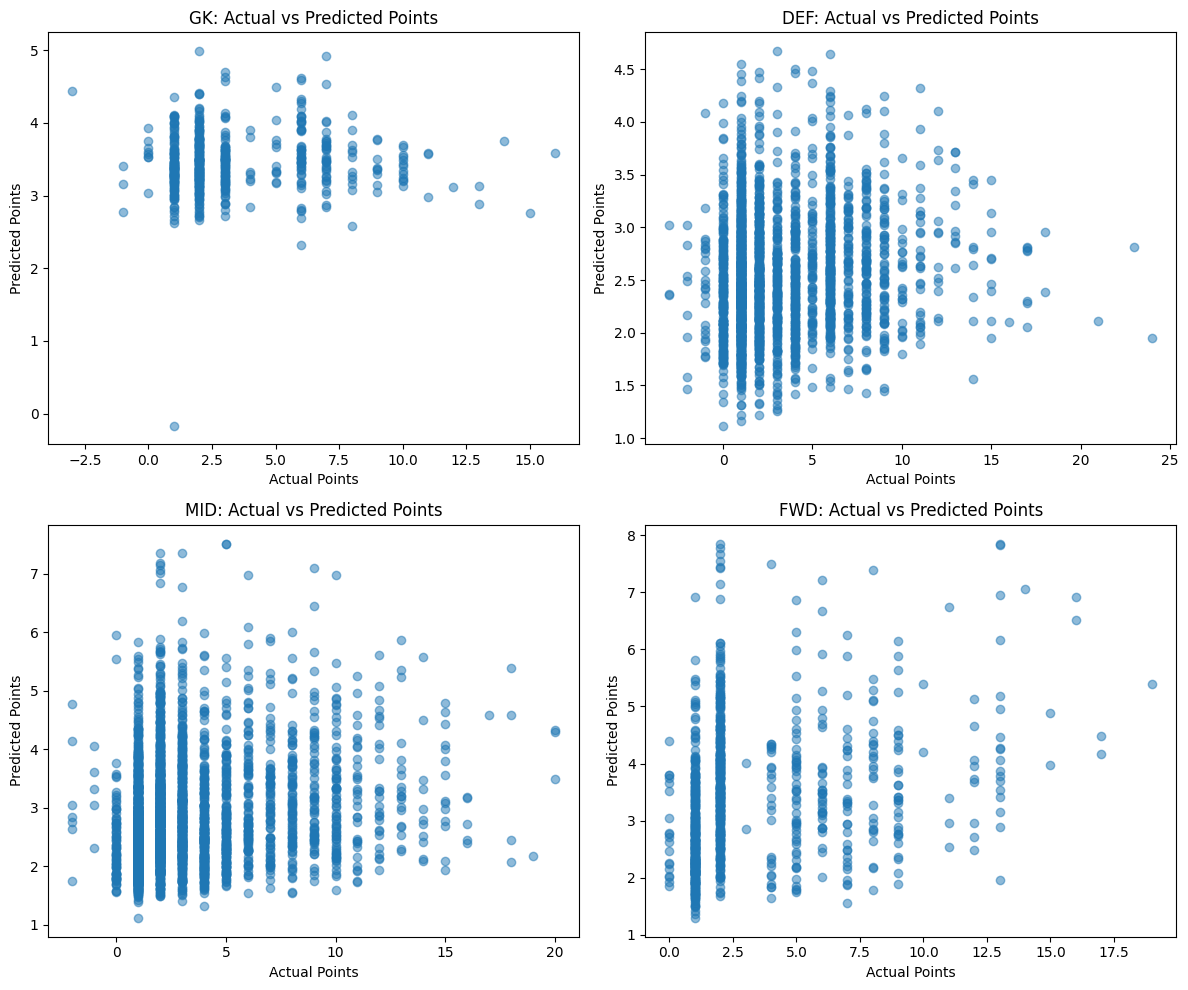

In [ ]:
# create object for model for each position
model_gk = LinearRegression(fit_intercept = True)
model_def = LinearRegression(fit_intercept = True)
model_mid = LinearRegression(fit_intercept = True)
model_fwd = LinearRegression(fit_intercept = True)

# fit each model with training data
model_gk.fit(X_train_gk_scaled , Y_train_gk)
model_def.fit(X_train_def_scaled , Y_train_def)
model_mid.fit(X_train_mid_scaled , Y_train_mid)
model_fwd.fit(X_train_fwd_scaled , Y_train_fwd)

# see how model predicts test data
f_gk = model_gk.predict(X_test_gk_scaled)
f_def = model_def.predict(X_test_def_scaled)
f_mid = model_mid.predict(X_test_mid_scaled)
f_fwd = model_fwd.predict(X_test_fwd_scaled)

# calculate MSE
mse_gk = mean_squared_error(Y_test_gk, f_gk)
mse_def = mean_squared_error(Y_test_def, f_def)
mse_mid= mean_squared_error(Y_test_mid, f_mid)
mse_fwd = mean_squared_error(Y_test_fwd, f_fwd)
print(f'GK MSE: {mse_gk}')
print(f'DEF MSE: {mse_def}')
print(f'MID MSE: {mse_mid}')
print(f'FWD MSE: {mse_fwd}')

# plot function to show predicted points vs actual points
def plotter(test, pred, position, ax):
  ax.scatter(test, pred, alpha = 0.5)
  ax.set_title(f'{position}: Actual vs Predicted Points')
  ax.set_xlabel('Actual Points')
  ax.set_ylabel('Predicted Points')

# define and plot subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plotter(Y_test_gk, f_gk, 'GK', axes[0, 0])
plotter(Y_test_def, f_def, 'DEF', axes[0, 1])
plotter(Y_test_mid, f_mid, 'MID', axes[1, 0])
plotter(Y_test_fwd, f_fwd, 'FWD', axes[1, 1])

plt.tight_layout()
plt.show()


## Apply Random Forest

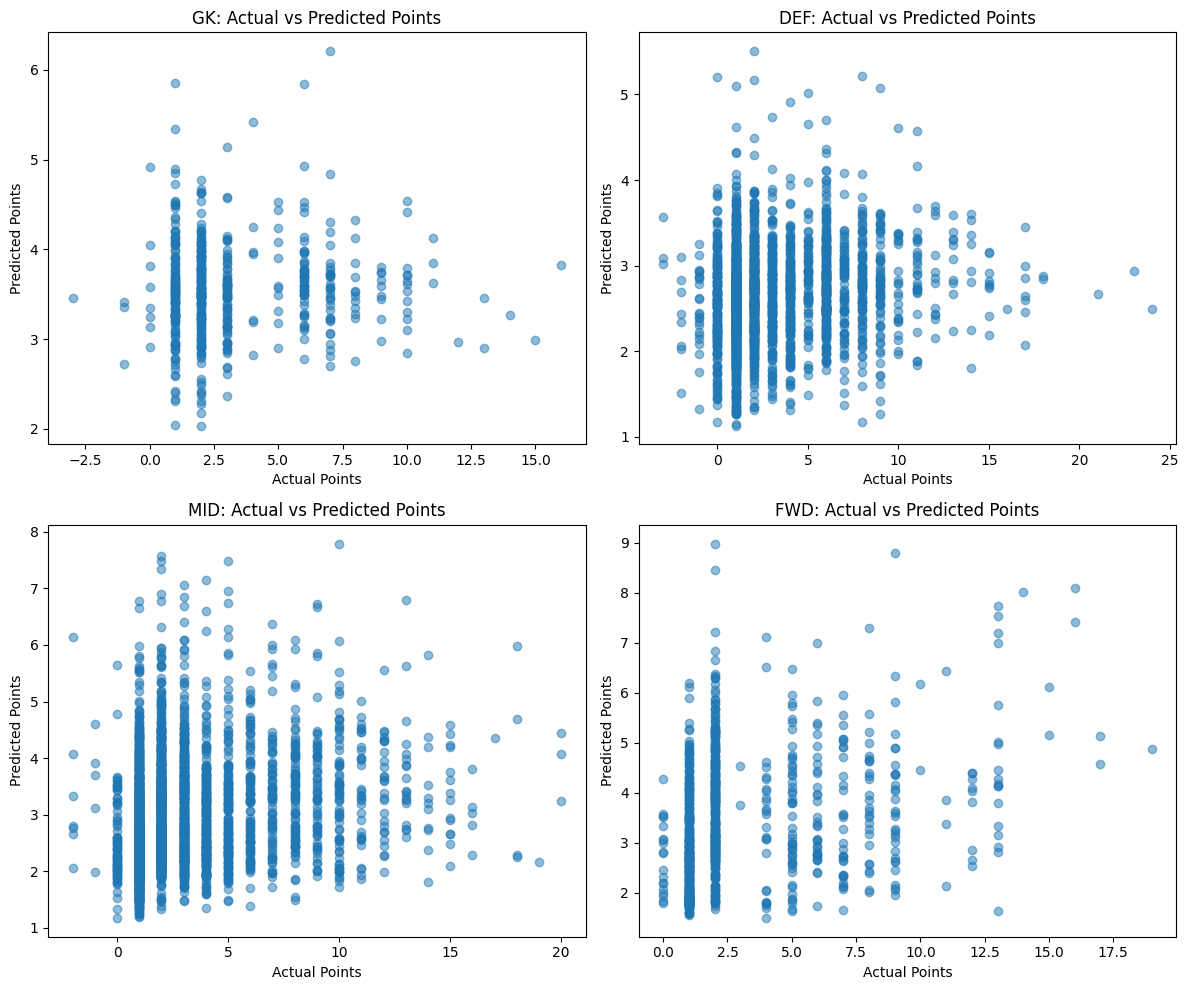

In [ ]:
# create object for model for each position
model_gk = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_def = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_mid = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_fwd = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)

# fit each model with training data
model_gk.fit(X_train_gk, Y_train_gk)
model_def.fit(X_train_def, Y_train_def)
model_mid.fit(X_train_mid, Y_train_mid)
model_fwd.fit(X_train_fwd, Y_train_fwd)

# see how model predicts test data
f_gk = model_gk.predict(X_test_gk)
f_def = model_def.predict(X_test_def)
f_mid = model_mid.predict(X_test_mid)
f_fwd = model_fwd.predict(X_test_fwd)

# define and plot subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plotter(Y_test_gk, f_gk, 'GK', axes[0, 0])
plotter(Y_test_def, f_def, 'DEF', axes[0, 1])
plotter(Y_test_mid, f_mid, 'MID', axes[1, 0])
plotter(Y_test_fwd, f_fwd, 'FWD', axes[1, 1])

plt.tight_layout()
plt.show()